In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def estimate_pi(n):
    x = np.random.uniform(0, 1, n)
    y = np.random.uniform(0, 1, n)
    inside = np.where(x**2 + y**2 <= 1, 1, 0)
    df = pd.DataFrame({'x': x, 'y': y, 'inside': inside})
    df['id'] = range(1, len(df)+1)
    df['pi'] = 4 * df['inside'].cumsum() / df['id']
    
    return df

In [3]:
pi_df = []
for _ in range(5):
    pi_df.append(estimate_pi(100000))
pi_df[2].tail()

,x,y,inside,id,pi
99995,0.891778,0.084069,1,99996,3.137485
99996,0.633159,0.210471,1,99997,3.137494
99997,0.540055,0.296610,1,99998,3.137503
99998,0.020993,0.055374,1,99999,3.137511
99999,0.277629,0.706377,1,100000,3.137520


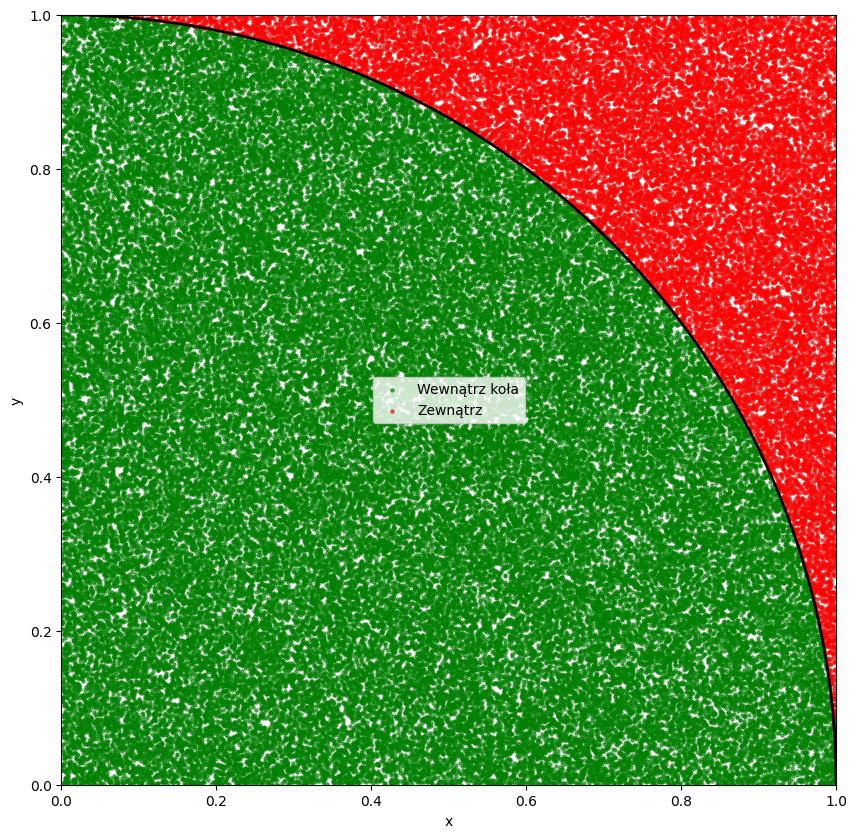

In [4]:
fig, ax = plt.subplots(figsize = (10,10), facecolor = "white")

df = pi_df[2]

df[df["inside"] == 1].plot.scatter(
    x='x',
    y='y',
    color = "green",
    s = 5,
    alpha = 0.6,
    ax = ax,
    label = "Wewnątrz koła"
)

df[df["inside"] == 0].plot.scatter(
    x='x', 
    y='y', 
    color="red", 
    s=5, 
    alpha=0.6, 
    ax=ax,
    label="Zewnątrz"
)

x = np.linspace(0, 1, 1000)
y = np.sqrt(1 - x**2)

ax.plot(
    x,
    y,
    color = "black",
    linewidth = 2,
    label = "Granica 1/4 koła"
)

ax.set_xlim(0,1)
ax.set_ylim(0,1)

plt.show()

(2.88, 3.4)

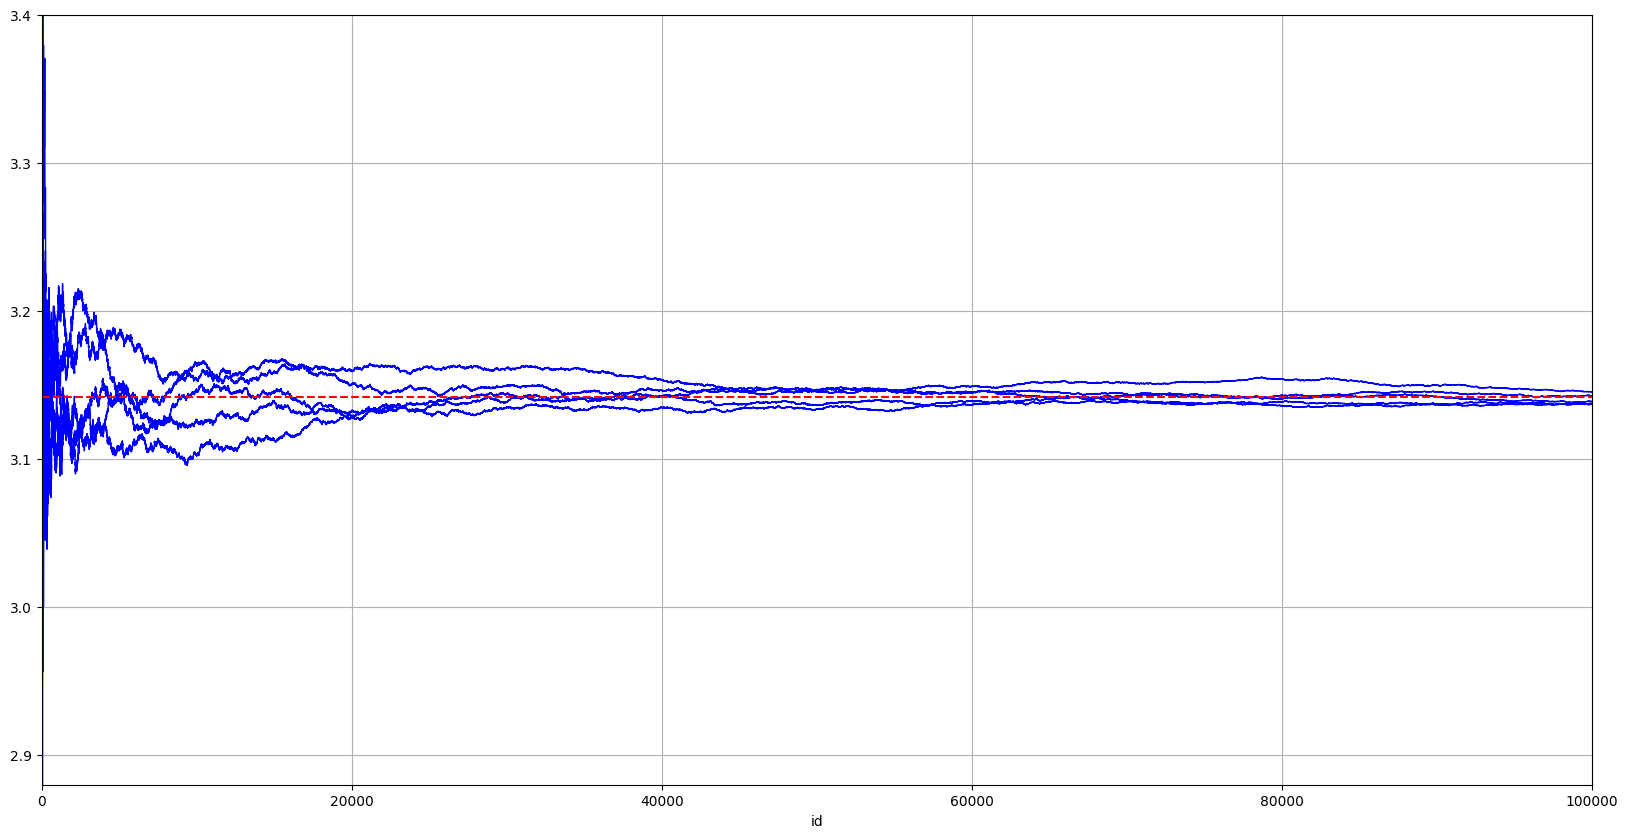

In [5]:
fig, ax = plt.subplots(figsize = (20,10), facecolor = "white")


for i in range(0, 5):
    pi_df[i].plot(
        x = 'id',
        y = 'pi',
        ax = ax,
        color = 'blue',
        lw = 1,
        legend = False
    )
ax.axhline(y = np.pi, color = "red", linestyle = '--')
ax.grid(True)
ax.set_xlim(0, 100000)
ax.set_ylim(2.88, 3.4)

In [48]:
def buffon(n, l, t):
    x = np.random.uniform(-50,50,n)
    y = np.random.uniform(-50,50,n)
    degree = np.random.uniform(0, 2*np.pi,n)
    xk = x + l*np.cos(degree)
    yk = y + l*np.sin(degree)
    lines = np.arange(-50,50+t,t)
    cut = np.zeros(n)
    for line in lines:
        condition = ((y <= line) & (yk >= line)) | ((yk <= line) & (y >= line))
        cut = np.where(condition, 1, cut)
    
    df = pd.DataFrame({
        'xp': x,
        'yp': y,
        'xk': xk,
        'yk': yk,
        'cut': cut
    })
    
    ids = range(1, len(df)+1)
    df['id'] = ids
    
    df['cuts'] = df['cut'].cumsum()
    
    df['pi'] = (2*l*df['id']) / (t*df['cuts'])
    df['pi'] = df['pi'].replace([np.inf, -np.inf], np.nan)
    
    return df, lines

In [49]:
df, lines = buffon(100000, 0.5, 1)

df.tail()

,xp,yp,xk,yk,cut,id,cuts,pi
99995,-1.741695,-3.775856,-2.232639,-3.681128,0.0,99996,31998.0,3.125070
99996,-46.163344,45.538368,-46.583401,45.809573,0.0,99997,31998.0,3.125102
99997,29.446426,-48.326738,28.993692,-48.114529,0.0,99998,31998.0,3.125133
99998,46.286627,7.090681,45.801256,7.210745,0.0,99999,31998.0,3.125164
99999,25.496652,20.942045,25.736882,21.380553,1.0,100000,31999.0,3.125098


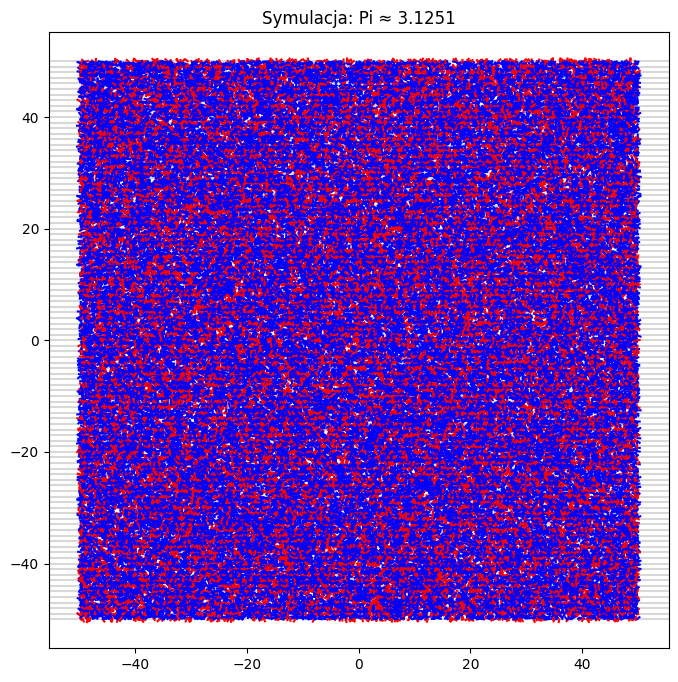

In [50]:
plt.figure(figsize=(8, 8))

for l in lines:
    plt.axhline(l, color='gray', alpha=0.3)

for i in range(len(df)):
    kolor = 'red' if df['cut'].iloc[i] == 1 else 'blue'
    
    plt.plot([df['xp'].iloc[i], df['xk'].iloc[i]], 
             [df['yp'].iloc[i], df['yk'].iloc[i]], 
             color=kolor)

plt.axis('equal')
plt.title(f"Symulacja: Pi ≈ {df['pi'].iloc[-1]:.4f}")
plt.show()